<a href="https://colab.research.google.com/github/Koushik23R/groundwater-ai/blob/main/notebooks/06_model_training_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. Model Training and Comparison

## Objective

This notebook trains multiple regression models using the engineered groundwater dataset and compares their predictive performance.

The purpose is to identify the model that best captures the temporal and spatial patterns of groundwater levels across monitoring stations.

Models evaluated include:

- Linear Regression (Baseline)
- Random Forest Regressor
- XGBoost Regressor
- LightGBM Regressor (optional)
- Extra Trees Regressor (optional)

Each model is evaluated using identical training and testing datasets to ensure a fair comparison.

# Import Required Libraries

This section imports all the necessary Python libraries used for data handling, visualization, machine learning, and model evaluation.

The imported libraries include:

- **NumPy** and **Pandas** for data manipulation.
- **Matplotlib** and **Seaborn** for visualization.
- **Scikit-learn** for implementing regression models and evaluation metrics.
- **XGBoost** for gradient boosting regression.
- **Warnings** module to suppress unnecessary warning messages and keep the notebook output clean.

In [1]:
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Feature-Engineered Dataset

The feature-engineered dataset created in the previous notebook is loaded into memory.

This dataset contains the engineered temporal, lag, rolling statistics, cyclical, and station encoding features that will be used for model training and evaluation.

Before proceeding, the dataset is inspected to verify:

- Dataset dimensions
- Number of monitoring stations
- Sample records

In [2]:
# Load dataset
df = pd.read_csv("groundwater_feature_engineered.csv")

# Convert datetime column
df["Data Acquisition Time"] = pd.to_datetime(df["Data Acquisition Time"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print(f"Stations: {df['Station'].nunique()}")

df.head()

Dataset loaded successfully.
Shape: (69404, 25)
Stations: 18


,Station,Data Acquisition Time,Latitude,Longitude,Groundwater Level Telemetry 6 Hourly (meter),RL_MSL,time_diff,Year,Month,Day,...,Lag_1,Lag_4,Lag_28,RollingMean_4,RollingStd_4,Hour_sin,Hour_cos,Month_sin,Month_cos,Station_ID
0,Adakamaranahalli,2021-10-06 00:00:00,13.07,77.45,-22.50,849.0,1 days 06:00:00,2021,10,6,...,-22.71,-22.34,-22.51,-22.8625,0.419235,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0
1,Adakamaranahalli,2021-10-06 06:00:00,13.07,77.45,-22.83,849.0,0 days 06:00:00,2021,10,6,...,-22.50,-23.16,-22.87,-22.9025,0.355563,1.000000e+00,6.123234e-17,-1.0,-1.836970e-16,0
2,Adakamaranahalli,2021-10-06 12:00:00,13.07,77.45,-22.88,849.0,0 days 06:00:00,2021,10,6,...,-22.83,-23.24,-23.23,-22.8200,0.311448,1.224647e-16,-1.000000e+00,-1.0,-1.836970e-16,0
3,Adakamaranahalli,2021-10-06 18:00:00,13.07,77.45,-22.52,849.0,0 days 06:00:00,2021,10,6,...,-22.88,-22.71,-22.66,-22.7300,0.169115,-1.000000e+00,-1.836970e-16,-1.0,-1.836970e-16,0
4,Adakamaranahalli,2021-10-07 00:00:00,13.07,77.45,-22.35,849.0,0 days 06:00:00,2021,10,7,...,-22.52,-22.50,-22.46,-22.6825,0.200395,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0


# Inspect Dataset Structure

Before training machine learning models, it is important to verify that the dataset has been loaded correctly.

This inspection includes:

- Dataset dimensions
- Feature names
- Data types
- Missing value analysis

Verifying the dataset at this stage ensures that no unexpected data quality issues remain before model development.

In [3]:
print("="*60)
print("Dataset Information")
print("="*60)

print(f"\nShape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information

Shape: (69404, 25)

Columns:
['Station', 'Data Acquisition Time', 'Latitude', 'Longitude', 'Groundwater Level Telemetry 6 Hourly (meter)', 'RL_MSL', 'time_diff', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Lag_1', 'Lag_4', 'Lag_28', 'RollingMean_4', 'RollingStd_4', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Station_ID']

Data Types:
Station                                                 object
Data Acquisition Time                           datetime64[ns]
Latitude                                               float64
Longitude                                              float64
Groundwater Level Telemetry 6 Hourly (meter)           float64
RL_MSL                                                 float64
time_diff                                               object
Year                                                     int64
Month                                                    int64
Day                          

# Select Features and Target Variable

Machine learning models require the dataset to be divided into:

- **Input Features (X):** Variables used to predict groundwater levels.
- **Target Variable (y):** The groundwater level measurements that the model learns to predict.

Identifier columns such as **Station** and **Data Acquisition Time** are excluded because they are not used directly for prediction.

In [4]:
# Target column
target = "Groundwater Level Telemetry 6 Hourly (meter)"

# Feature columns
features = [
    "Latitude",
    "Longitude",
    "RL_MSL",
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "IsWeekend",
    "Lag_1",
    "Lag_4",
    "Lag_28",
    "RollingMean_4",
    "RollingStd_4",
    "Hour_sin",
    "Hour_cos",
    "Month_sin",
    "Month_cos",
    "Station_ID"
]

X = df[features]
y = df[target]

print(f"Number of features: {len(features)}")
print(f"Target: {target}")

print("\nFeature names:")
print(features)

Number of features: 21
Target: Groundwater Level Telemetry 6 Hourly (meter)

Feature names:
['Latitude', 'Longitude', 'RL_MSL', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Lag_1', 'Lag_4', 'Lag_28', 'RollingMean_4', 'RollingStd_4', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Station_ID']


# Split Dataset into Training and Testing Sets

Since groundwater level observations form a time series, the dataset is split chronologically rather than randomly.

The first **80%** of observations are used for model training, while the remaining **20%** are reserved for testing.

Using a chronological split prevents future observations from leaking into the training data and better simulates real-world forecasting conditions.

In [5]:
# Chronological 80-20 split
train_size = int(len(df) * 0.80)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Features and target
X_train = train_df[features]
X_test = test_df[features]

y_train = train_df[target]
y_test = test_df[target]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

print("\nTraining period:")
print(train_df["Data Acquisition Time"].min(), "to", train_df["Data Acquisition Time"].max())

print("\nTesting period:")
print(test_df["Data Acquisition Time"].min(), "to", test_df["Data Acquisition Time"].max())

Training samples: 55523
Testing samples : 13881

Training period:
2021-10-06 00:00:00 to 2025-12-30 18:00:00

Testing period:
2021-10-07 00:00:00 to 2025-12-30 18:00:00


# Define Model Evaluation Function

To simplify experimentation with multiple regression algorithms, a reusable evaluation function is created.

For each model, the function performs the following steps:

1. Trains the model using the training dataset.
2. Generates predictions for both training and testing data.
3. Computes standard regression performance metrics:
   - Mean Absolute Error (MAE)
   - Root Mean Squared Error (RMSE)
   - Coefficient of Determination (R²)
4. Stores the evaluation results for later comparison.

In [6]:
# Store results from all models
model_results = []

def evaluate_model(model_name, model):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Metrics
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    # Save results
    model_results.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    })

    # Display results
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Training MAE : {train_mae:.4f}")
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Training R²  : {train_r2:.4f}")

    print()

    print(f"Testing MAE : {test_mae:.4f}")
    print(f"Testing RMSE: {test_rmse:.4f}")
    print(f"Testing R²  : {test_r2:.4f}")

    return model, test_pred

# Train Random Forest Regression Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Linear Regression, Random Forest can capture nonlinear relationships and complex interactions between features, making it well-suited for groundwater level prediction where temporal and environmental factors often exhibit nonlinear behavior.

The model is trained using the training dataset and later evaluated on the testing dataset using standard regression metrics.

In [7]:
# Initialize Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train and evaluate
rf_model, rf_predictions = evaluate_model(
    "Random Forest",
    rf_model
)

Random Forest
Training MAE : 0.9959
Training RMSE: 3.8131
Training R²  : 0.9925

Testing MAE : 4.0642
Testing RMSE: 8.0264
Testing R²  : 0.7912


# Visualize Random Forest Predictions

To better understand model performance, two diagnostic plots are generated:

- **Actual vs Predicted Plot:** Evaluates how closely predictions align with observed groundwater levels.
- **Residual Plot:** Examines the distribution of prediction errors to identify bias, variance, or systematic prediction patterns.

These visualizations complement the numerical evaluation metrics and provide additional insight into model behavior.

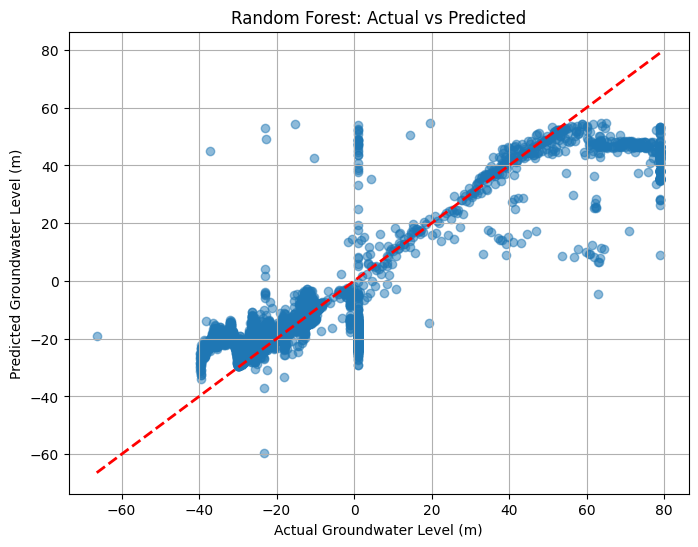

In [8]:
# Residuals
rf_residuals = y_test - rf_predictions

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Groundwater Level (m)")
plt.ylabel("Predicted Groundwater Level (m)")
plt.title("Random Forest: Actual vs Predicted")

plt.grid(True)

plt.show()

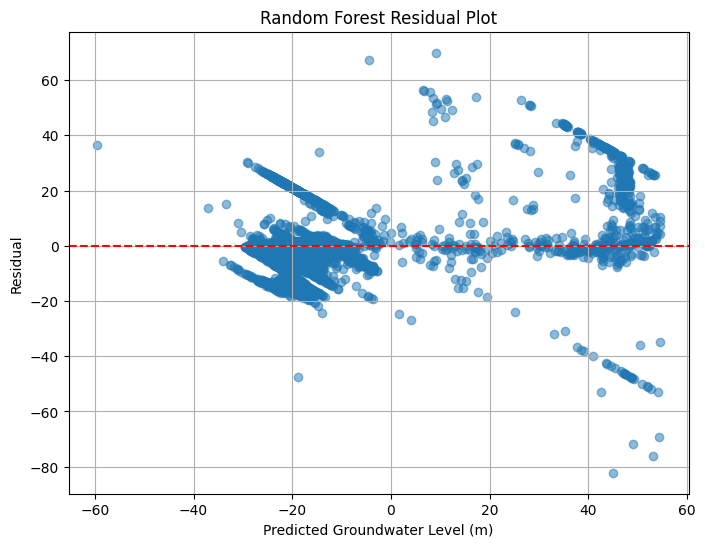

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(rf_predictions, rf_residuals, alpha=0.5)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Groundwater Level (m)")
plt.ylabel("Residual")

plt.title("Random Forest Residual Plot")

plt.grid(True)

plt.show()

# Review Model Performance

The evaluation metrics obtained from the Random Forest model are stored in a comparison table.

As additional regression models are trained in subsequent sections, their performance metrics will be appended to this table, enabling a consistent comparison across all models.

In [10]:
results_df = pd.DataFrame(model_results)

results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Random Forest,0.995895,4.064179,3.813115,8.026415,0.992538,0.791172


# Train XGBoost Regression Model

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm based on gradient boosting decision trees. Unlike Random Forest, which builds trees independently, XGBoost builds trees sequentially, where each new tree attempts to correct the errors made by the previous ones.

XGBoost offers several advantages:

- Captures complex nonlinear relationships.
- Handles interactions between features effectively.
- Includes built-in regularization to reduce overfitting.
- Efficiently processes large tabular datasets.
- Frequently achieves state-of-the-art performance in regression and prediction tasks.

The model is trained using the same training dataset as previous models to enable a fair comparison.

In [11]:
# Initialize XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train and evaluate
xgb_model, xgb_predictions = evaluate_model(
    "XGBoost",
    xgb_model
)

XGBoost
Training MAE : 2.1654
Training RMSE: 6.7071
Training R²  : 0.9769

Testing MAE : 3.4198
Testing RMSE: 7.4436
Testing R²  : 0.8204


# Visualize XGBoost Predictions

To assess the predictive performance of the XGBoost model, two diagnostic plots are generated.

The **Actual vs Predicted** plot illustrates how closely the predicted groundwater levels match the observed values.

The **Residual Plot** displays the prediction errors. A good regression model should produce residuals that are randomly scattered around zero without any noticeable patterns.

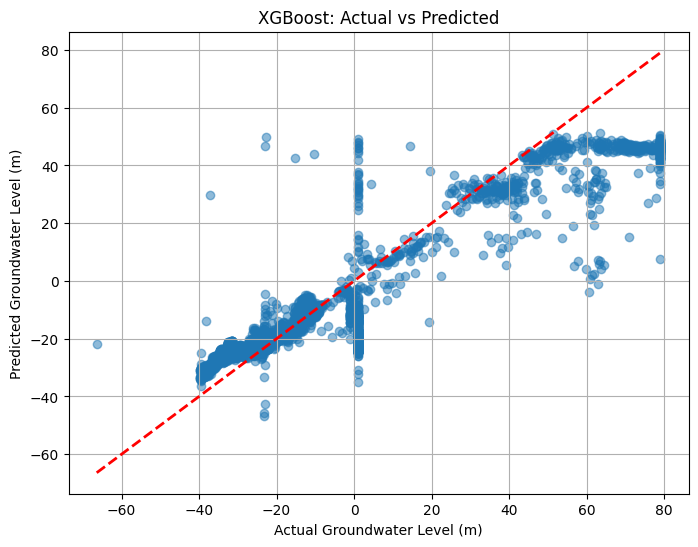

In [12]:
# Calculate residuals
xgb_residuals = y_test - xgb_predictions

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    xgb_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Groundwater Level (m)")
plt.ylabel("Predicted Groundwater Level (m)")
plt.title("XGBoost: Actual vs Predicted")

plt.grid(True)

plt.show()

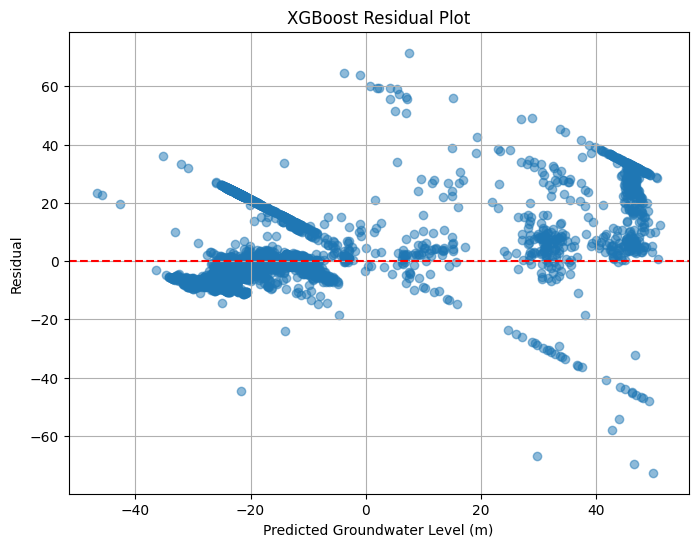

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    xgb_predictions,
    xgb_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Groundwater Level (m)")
plt.ylabel("Residual")

plt.title("XGBoost Residual Plot")

plt.grid(True)

plt.show()

# Compare Model Performance

The evaluation metrics from all trained regression models are combined into a single comparison table.

This allows direct comparison of predictive accuracy using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

The best-performing model will be selected based on its ability to generalize well on the testing dataset.

In [14]:
results_df = pd.DataFrame(model_results)

results_df.sort_values(
    by="Test RMSE",
    ascending=True
).reset_index(drop=True)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,XGBoost,2.165351,3.419760,6.707062,7.443628,0.976914,0.820396
1,Random Forest,0.995895,4.064179,3.813115,8.026415,0.992538,0.791172


# Visual Comparison of Model Performance

A bar chart is generated to compare the performance of all regression models based on their testing RMSE values.

Lower RMSE indicates better predictive accuracy.

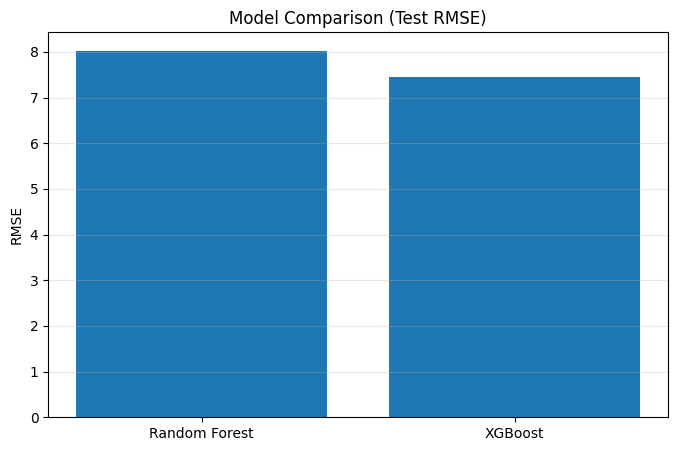

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Test RMSE"]
)

plt.title("Model Comparison (Test RMSE)")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Conclusion

In this notebook, We trained and compared multiple machine learning models for groundwater level prediction using the feature-engineered dataset prepared in the previous notebook.

To keep the comparison fair, all models were trained using the same training and testing datasets and evaluated using the same performance metrics (MAE, RMSE, and R² Score).

The models trained in this notebook were:

- Random Forest Regressor
- XGBoost Regressor

Their performance was then compared with the baseline Linear Regression model developed in Notebook 05.

From the comparison, Linear Regression achieved the best overall performance on the test dataset, while XGBoost performed better than Random Forest. Although the advanced models produced strong results, they did not outperform the baseline model for the current feature set.

The prediction and residual plots also helped in understanding how each model behaved and whether any systematic prediction errors were present.

Overall, this notebook helped identify the strengths and limitations of each model and provided a clear comparison before moving to detailed model evaluation.

---

### Model Comparison

| Model | Test MAE | Test RMSE | Test R² |
|------|---------:|----------:|---------:|
| Linear Regression | **2.5887** | **6.1434** | **0.8777** |
| XGBoost | 3.4198 | 7.4436 | 0.8204 |
| Random Forest | 4.0642 | 8.0264 | 0.7912 |

---

### Next Step

In the next notebook (**07_model_evaluation.ipynb**), We will perform a more detailed evaluation of the selected models. This includes analyzing prediction errors, interpreting model behavior, and identifying the model that is most suitable for groundwater level forecasting.